In [16]:
import pandas as pd 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error

In [17]:
df = sns.load_dataset('diamonds')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


0.803392658509455
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       335
           1       0.81      0.72      0.76      1004
           2       0.83      0.92      0.87      4292
           3       0.82      0.82      0.82      2775
           4       0.71      0.60      0.65      2382

    accuracy                           0.80     10788
   macro avg       0.82      0.79      0.80     10788
weighted avg       0.80      0.80      0.80     10788



<Axes: >

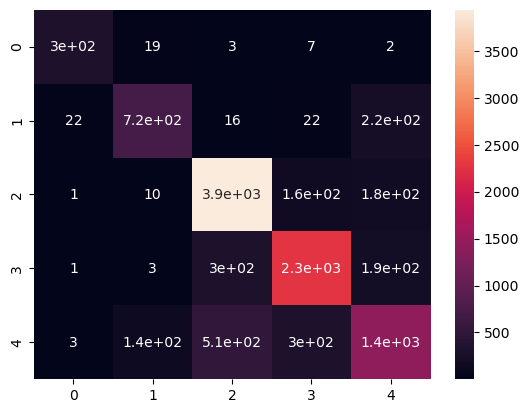

In [18]:
for col in df.select_dtypes('category').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    
X = df.drop('cut', axis=1)
y = df['cut']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

0.7878197997775306
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       335
           1       0.78      0.71      0.74      1004
           2       0.83      0.92      0.87      4292
           3       0.78      0.82      0.80      2775
           4       0.69      0.54      0.60      2382

    accuracy                           0.79     10788
   macro avg       0.80      0.78      0.78     10788
weighted avg       0.78      0.79      0.78     10788



<Axes: >

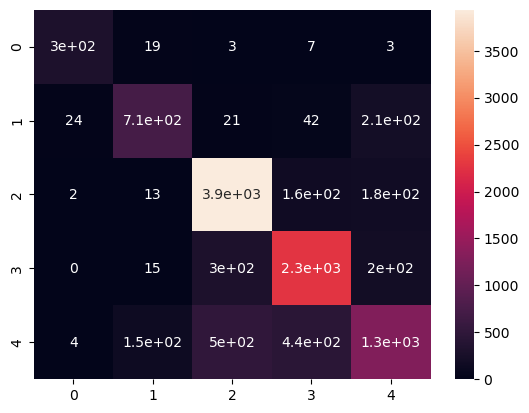

In [19]:
for col in df.select_dtypes('category').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    
X = df.drop('cut', axis=1)
y = df['cut']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

0.7152391546162402
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       335
           1       0.66      0.69      0.67      1004
           2       0.80      0.79      0.80      4292
           3       0.74      0.73      0.74      2775
           4       0.54      0.55      0.54      2382

    accuracy                           0.72     10788
   macro avg       0.72      0.72      0.72     10788
weighted avg       0.72      0.72      0.72     10788



<Axes: >

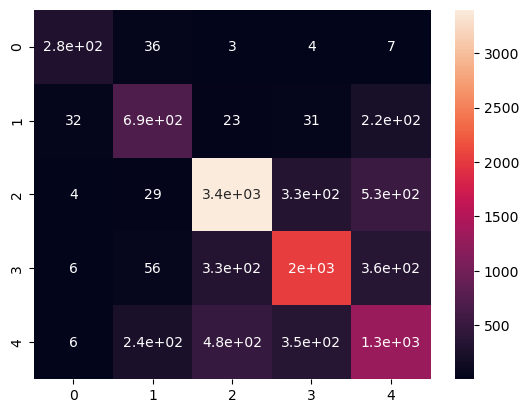

In [20]:
for col in df.select_dtypes('category').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    
X = df.drop('cut', axis=1)
y = df['cut']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [22]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'R^2: {r2_score(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')

R^2: 0.9812760353088379
MSE: 297651.25
MAE: 277.9412841796875
MAPE: 0.07264555245637894


In [23]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'R^2: {r2_score(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')

R^2: 0.9669548997324523
MSE: 525312.0587921765
MAE: 353.61322766036335
MAPE: 0.08408339484355509


In [24]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'R^2: {r2_score(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')

R^2: 0.9815091084381835
MSE: 293946.40163279924
MAE: 267.95404022547103
MAPE: 0.06395182649865501


In [25]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'R^2: {r2_score(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')

R^2: 0.8851397433679632
MSE: 1825912.9915253469
MAE: 858.7084697710069
MAPE: 0.3886960085889152


In [26]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'R^2: {r2_score(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')

R^2: 0.8851397433679632
MSE: 1825912.9915253469
MAE: 858.7084697710069
MAPE: 0.3886960085889152
